# Diana Ruiz Moctezuma
## Telecom X — Parte 2: Modelado Predictivo de Churn

## Carga y Preparación de Datos

In [36]:
# Librerias
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [37]:
with open("TelecomX_Data.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

df = pd.json_normalize(raw)

print("Dimensiones iniciales:", df.shape)
df.head()

Dimensiones iniciales: (7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [38]:
# Limpieza básica
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [39]:
# Convertir columnas numéricas necesarias
df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"],
    errors="coerce"
)

# Eliminar duplicados
df = df.drop_duplicates()

# Eliminar filas con target nulo si existieran
df = df.dropna(subset=["Churn"])

# Eliminar columnas irrelevantes
# customerID es identificador y no aporta valor predictivo real
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

print("Dimensiones después de limpieza inicial:", df.shape)

Dimensiones después de limpieza inicial: (7267, 20)


In [40]:
# Creación de variable objetivo
df["Churn_bin"] = df["Churn"].map({"Yes": 1, "No": 0})
df = df.drop(columns=["Churn"])

df["Churn_bin"].value_counts()

,count
Churn_bin,
0.0,5174
1.0,1869


In [41]:
class_counts = df["Churn_bin"].value_counts().sort_index()
class_pct = df["Churn_bin"].value_counts(normalize=True).sort_index() * 100

print("Distribución de clases:")
print(class_counts)
print("\nPorcentaje de clases:")
print(class_pct.round(2))

Distribución de clases:
Churn_bin
0.0    5174
1.0    1869
Name: count, dtype: int64

Porcentaje de clases:
Churn_bin
0.0    73.46
1.0    26.54
Name: proportion, dtype: float64


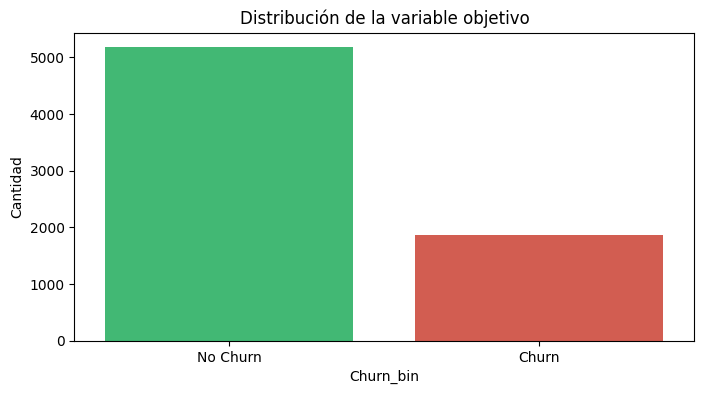

In [42]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Churn_bin", palette=["#2ECC71", "#E74C3C"])
plt.title("Distribución de la variable objetivo")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.ylabel("Cantidad")
plt.show()

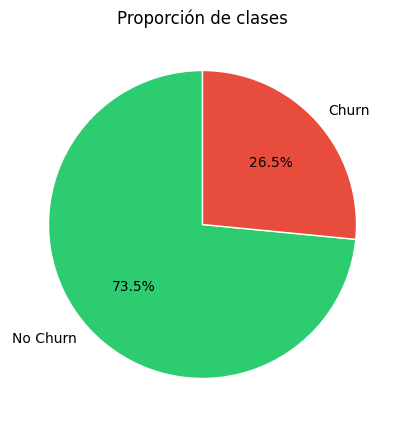

In [43]:
plt.figure(figsize=(5, 5))
plt.pie(
    class_counts.values,
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%",
    colors=["#2ECC71", "#E74C3C"],
    startangle=90,
    wedgeprops={"edgecolor": "white"}
)
plt.title("Proporción de clases")
plt.show()

### Interpretación del balance de clases

El dataset presenta desbalance moderado entre clientes que permanecen y clientes que cancelan.  
No se aplicará sobremuestreo en esta etapa; en su lugar, se usarán métricas adecuadas y, en algunos modelos, `class_weight='balanced'`.

## Revisión de valores faltantes

In [44]:
### Interpretación del balance de clases

missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

,0
Churn_bin,224
account.Charges.Total,11


In [45]:
# Imputación simple para Total Charges si quedó algún nulo tras la conversión
if df["account.Charges.Total"].isnull().sum() > 0:
    df["account.Charges.Total"] = df["account.Charges.Total"].fillna(
        df["account.Charges.Total"].median()
    )

df.isnull().sum().sum()

np.int64(224)

In [46]:
# Convertir variables binarias Yes/No restantes a 1/0
binary_cols = []

for col in df.columns:
    unique_vals = set(df[col].dropna().unique())
    if unique_vals == {"Yes", "No"}:
        binary_cols.append(col)

for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

binary_cols

['customer.Partner',
 'customer.Dependents',
 'phone.PhoneService',
 'account.PaperlessBilling']

In [47]:
# One-hot encoding para variables categóricas restantes
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Dimensiones después de encoding:", df_encoded.shape)
df_encoded.head()

Dimensiones después de encoding: (7267, 31)


,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Churn_bin,customer.gender_Male,...,internet.TechSupport_Yes,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,1,1,9,1,1,65.6,593.30,0.0,False,...,True,False,True,False,False,True,False,False,False,True
1,0,0,0,9,1,0,59.9,542.40,0.0,True,...,False,False,False,False,True,False,False,False,False,True
2,0,0,0,4,1,1,73.9,280.85,1.0,True,...,False,False,False,False,False,False,False,False,True,False
3,1,1,0,13,1,1,98.0,1237.85,1.0,True,...,False,False,True,False,True,False,False,False,True,False
4,1,1,0,3,1,1,83.9,267.40,1.0,False,...,True,False,True,False,False,False,False,False,False,True


In [48]:
corr_target = df_encoded.corr(numeric_only=True)["Churn_bin"].drop("Churn_bin").sort_values(key=np.abs, ascending=False)

corr_target.head(15)

,Churn_bin
customer.tenure,-0.352229
internet.InternetService_Fiber optic,0.308020
account.Contract_Two year,-0.302253
account.PaymentMethod_Electronic check,0.301919
internet.InternetService_No,-0.227890
internet.OnlineSecurity_No internet service,-0.227890
internet.DeviceProtection_No internet service,-0.227890
internet.TechSupport_No internet service,-0.227890
internet.StreamingMovies_No internet service,-0.227890
internet.StreamingTV_No internet service,-0.227890


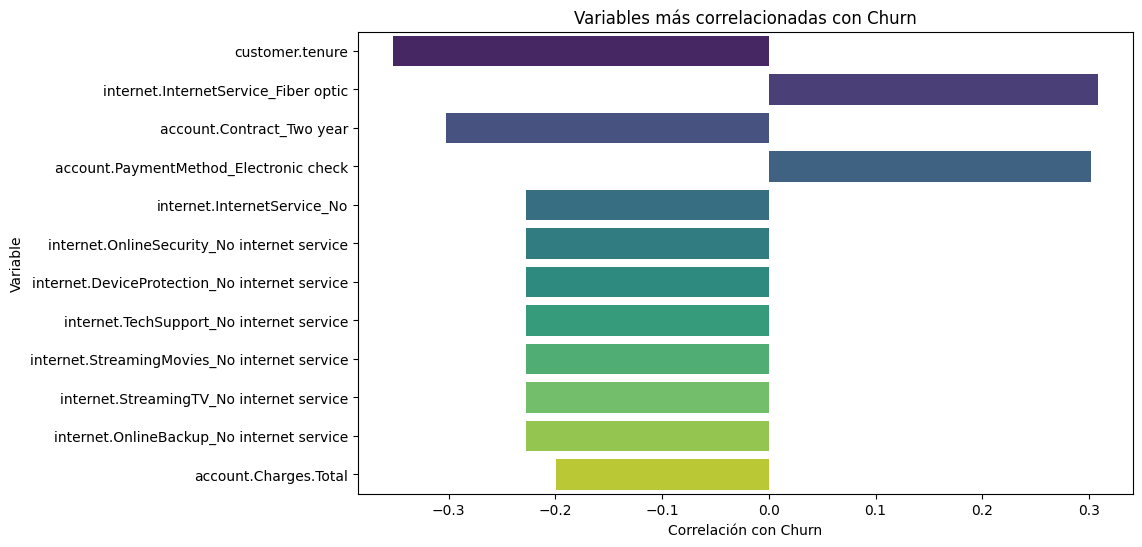

In [49]:
top_corr = corr_target.head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette="viridis")
plt.title("Variables más correlacionadas con Churn")
plt.xlabel("Correlación con Churn")
plt.ylabel("Variable")
plt.show()

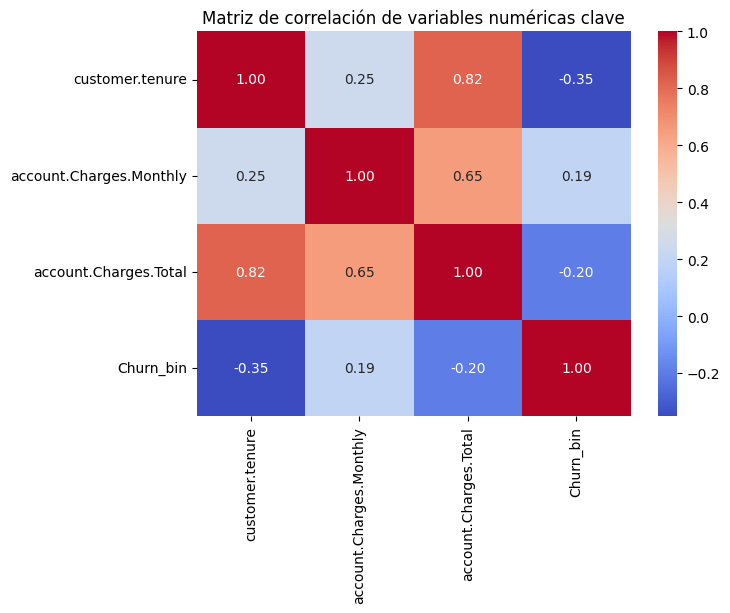

In [50]:
# Heatmap con variables numéricas principales
num_cols = [
    "customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total",
    "Churn_bin"
]

existing_num_cols = [c for c in num_cols if c in df_encoded.columns]

plt.figure(figsize=(7, 5))
sns.heatmap(
    df_encoded[existing_num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación de variables numéricas clave")
plt.show()

### Interpretación de correlación

La correlación permite identificar qué variables tienen una relación más fuerte con la cancelación.  
En general, variables como permanencia (`tenure`), cargos mensuales, cargos totales y ciertos tipos de contrato o servicios adicionales suelen mostrar relación importante con el churn.

In [51]:
# revisar valores faltantes
print("Valores faltantes:")
print(df_encoded.isnull().sum().sum())

# imputar si existen
df_encoded = df_encoded.fillna(df_encoded.median(numeric_only=True))

Valores faltantes:
224


In [52]:
X = df_encoded.drop(columns=["Churn_bin"])
y = df_encoded["Churn_bin"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (7267, 30)
Shape de y: (7267,)


## Split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=66,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)
print("\nProporción de churn en train:", round(y_train.mean(), 4))
print("Proporción de churn en test :", round(y_test.mean(), 4))

Train: (5813, 30) (5813,)
Test : (1454, 30) (1454,)

Proporción de churn en train: 0.2572
Proporción de churn en test : 0.2572


## Estandarización

In [54]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Nota sobre estandarización

La estandarización se aplica especialmente a modelos sensibles a la escala, como Regresión Logística, KNN y SVM.  
Random Forest no la necesita, pero se conservará aparte el conjunto sin escalar para ese modelo.

## Entrenamiento de modelos

In [59]:
def metricas_modelo(y_true, y_pred, y_prob, nombre):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    metricas_modelo(y_test, y_pred_lr, y_prob_lr, "Regresión Logística"),
    metricas_modelo(y_test, y_pred_knn, y_prob_knn, "KNN"),
    metricas_modelo(y_test, y_pred_rf, y_prob_rf, "Random Forest")
])

results = results.sort_values("F1 Score", ascending=False).reset_index(drop=True)
results

,Modelo,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Regresión Logística,0.729711,0.484848,0.812834,0.607393,0.843035
1,Random Forest,0.797111,0.631229,0.508021,0.562963,0.823705
2,KNN,0.764787,0.542328,0.548128,0.545213,0.780458


## Predicciones

In [58]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

## Métricas

In [78]:
def metricas_modelo(y_true, y_pred, y_prob, nombre):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    metricas_modelo(y_test, y_pred_lr, y_prob_lr, "Regresión Logística"),
    metricas_modelo(y_test, y_pred_knn, y_prob_knn, "KNN"),
    metricas_modelo(y_test, y_pred_rf, y_prob_rf, "Random Forest")
])

results = results.sort_values("F1 Score", ascending=False).reset_index(drop=True)
results

,Modelo,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Regresión Logística,0.729711,0.484848,0.812834,0.607393,0.843035
1,Random Forest,0.797111,0.631229,0.508021,0.562963,0.823705
2,KNN,0.764787,0.542328,0.548128,0.545213,0.780458


In [61]:
results_pct = results.copy()

for col in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]:
    results_pct[col] = (results_pct[col] * 100).round(2)

results_pct

,Modelo,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Regresión Logística,72.97,48.48,81.28,60.74,84.30
1,Random Forest,79.71,63.12,50.80,56.30,82.37
2,KNN,76.48,54.23,54.81,54.52,78.05


## Matrices de confusión

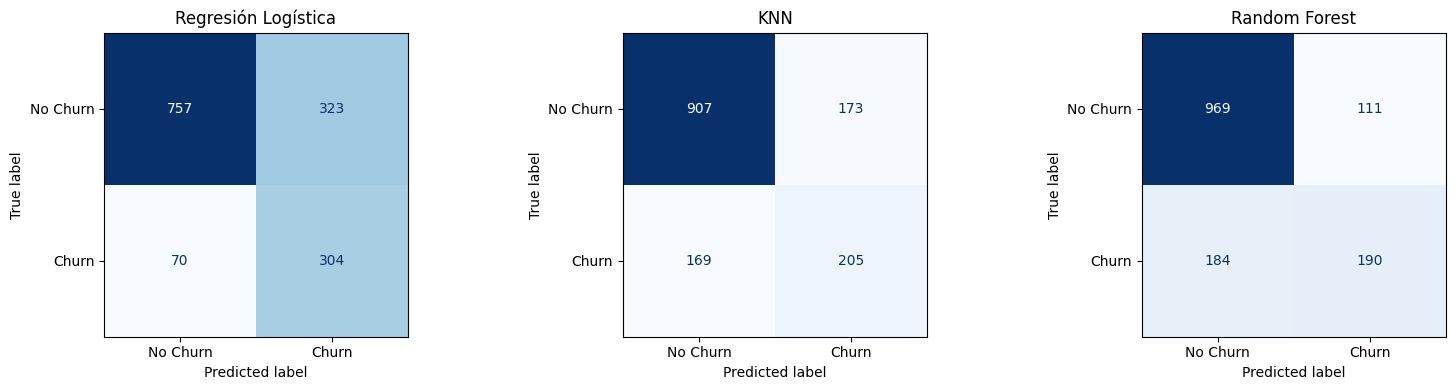

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

modelos_pred = [
    ("Regresión Logística", y_pred_lr),
    ("KNN", y_pred_knn),
    ("Random Forest", y_pred_rf)
]

for ax, (nombre, pred) in zip(axes, modelos_pred):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

In [63]:
print("Regresión Logística\n")
print(classification_report(y_test, y_pred_lr, target_names=["No Churn", "Churn"]))

print("KNN\n")
print(classification_report(y_test, y_pred_knn, target_names=["No Churn", "Churn"]))

print("Random Forest\n")
print(classification_report(y_test, y_pred_rf, target_names=["No Churn", "Churn"]))

Regresión Logística

              precision    recall  f1-score   support

    No Churn       0.92      0.70      0.79      1080
       Churn       0.48      0.81      0.61       374

    accuracy                           0.73      1454
   macro avg       0.70      0.76      0.70      1454
weighted avg       0.80      0.73      0.75      1454

KNN

              precision    recall  f1-score   support

    No Churn       0.84      0.84      0.84      1080
       Churn       0.54      0.55      0.55       374

    accuracy                           0.76      1454
   macro avg       0.69      0.69      0.69      1454
weighted avg       0.77      0.76      0.77      1454

Random Forest

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1080
       Churn       0.63      0.51      0.56       374

    accuracy                           0.80      1454
   macro avg       0.74      0.70      0.72      1454
weighted avg       0.79      0.80

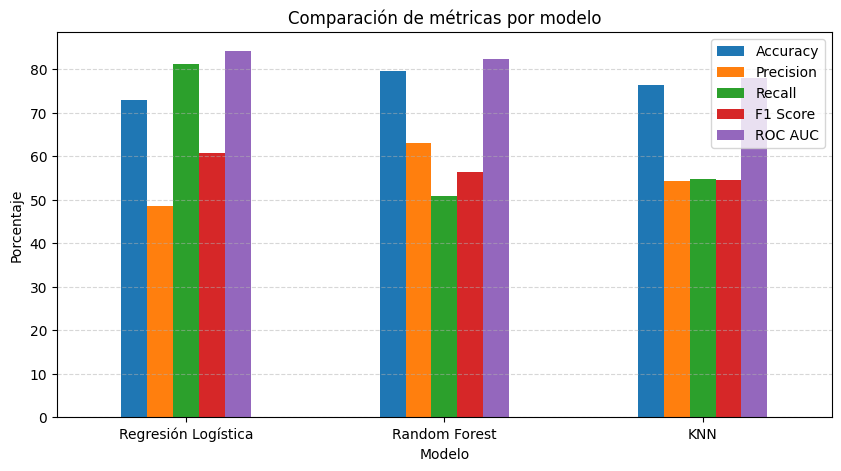

In [64]:
metrics_plot = results_pct.set_index("Modelo")

metrics_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Comparación de métricas por modelo")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## Curvas ROC

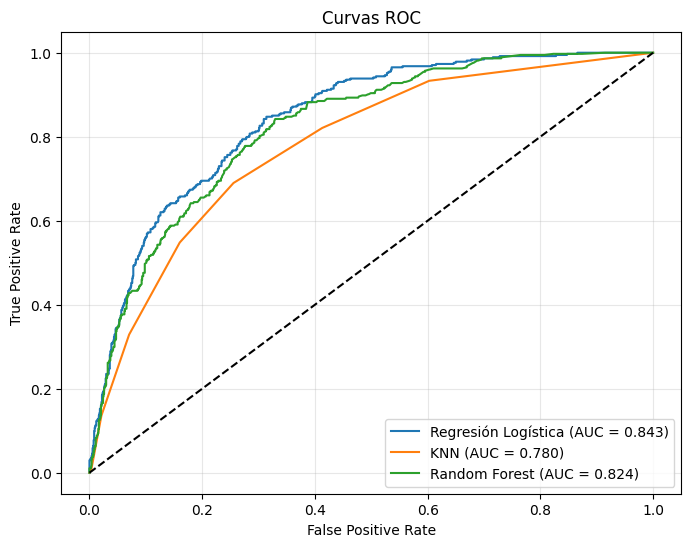

In [66]:
plt.figure(figsize=(8, 6))

for nombre, y_prob in [
    ("Regresión Logística", y_prob_lr),
    ("KNN", y_prob_knn),
    ("Random Forest", y_prob_rf)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Variables relevantes

## Regresión logística

In [67]:
# Variables más relevantes
coef_lr = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": lr.coef_[0]
})

coef_lr["Abs_Coef"] = coef_lr["Coeficiente"].abs()
coef_lr = coef_lr.sort_values("Abs_Coef", ascending=False)

coef_lr.head(15)

,Variable,Coeficiente,Abs_Coef
3,customer.tenure,-1.278552,1.278552
7,account.Charges.Total,0.641984,0.641984
26,account.Contract_Two year,-0.614144,0.614144
6,account.Charges.Monthly,-0.553247,0.553247
11,internet.InternetService_Fiber optic,0.543637,0.543637
25,account.Contract_One year,-0.303245,0.303245
24,internet.StreamingMovies_Yes,0.228290,0.228290
28,account.PaymentMethod_Electronic check,0.184570,0.184570
5,account.PaperlessBilling,0.174329,0.174329
22,internet.StreamingTV_Yes,0.151980,0.151980


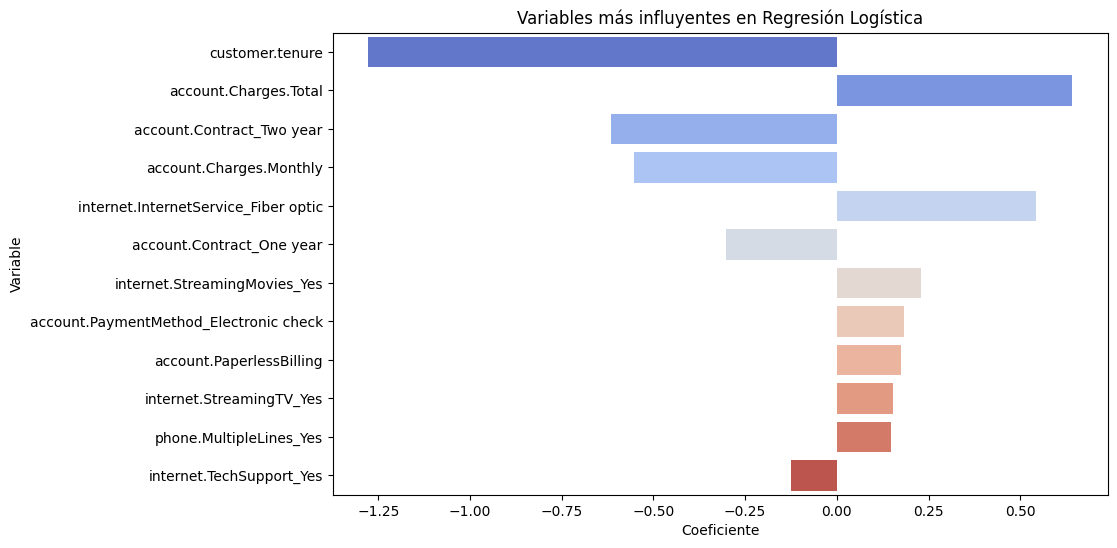

In [72]:
top_lr = coef_lr.head(12)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_lr, x="Coeficiente", y="Variable", palette="coolwarm")
plt.title("Variables más influyentes en Regresión Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.show()

### Interpretación de Regresión Logística

En este modelo, los coeficientes positivos indican variables que aumentan la probabilidad de churn, mientras que los coeficientes negativos indican variables asociadas con permanencia.  
Cuanto mayor es la magnitud absoluta del coeficiente, mayor es su influencia en la predicción.

In [73]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)

mean_0 = X_train_scaled_df[y_train == 0].mean()
mean_1 = X_train_scaled_df[y_train == 1].mean()

knn_proxy = pd.DataFrame({
    "Variable": X.columns,
    "Diferencia_promedio_estandarizada": (mean_1 - mean_0).abs().values
}).sort_values("Diferencia_promedio_estandarizada", ascending=False)

knn_proxy.head(15)

,Variable,Diferencia_promedio_estandarizada
3,customer.tenure,0.786732
11,internet.InternetService_Fiber optic,0.678856
28,account.PaymentMethod_Electronic check,0.676787
26,account.Contract_Two year,0.675309
12,internet.InternetService_No,0.512025
13,internet.OnlineSecurity_No internet service,0.512025
17,internet.DeviceProtection_No internet service,0.512025
19,internet.TechSupport_No internet service,0.512025
23,internet.StreamingMovies_No internet service,0.512025
21,internet.StreamingTV_No internet service,0.512025


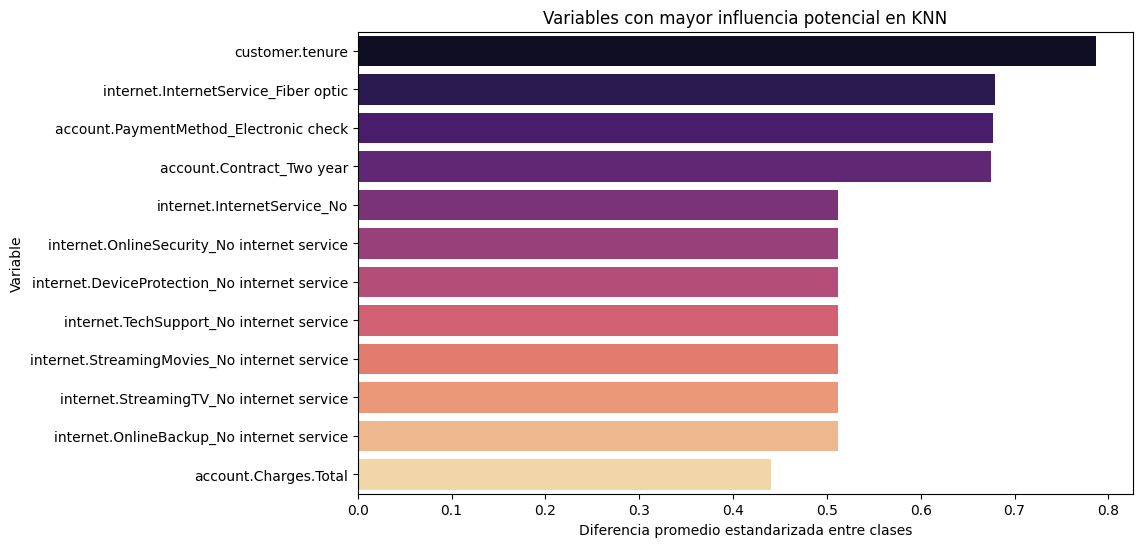

In [74]:
top_knn = knn_proxy.head(12)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_knn,
    x="Diferencia_promedio_estandarizada",
    y="Variable",
    palette="magma"
)
plt.title("Variables con mayor influencia potencial en KNN")
plt.xlabel("Diferencia promedio estandarizada entre clases")
plt.ylabel("Variable")
plt.show()

### Interpretación de KNN

KNN clasifica según los vecinos más cercanos en el espacio de variables estandarizadas.  
Por ello, las variables que generan mayor separación entre clientes con churn y sin churn tienden a influir más en la proximidad entre observaciones y, por tanto, en la clasificación final.

In [75]:
feat_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
}).sort_values("Importancia", ascending=False)

feat_rf.head(15)

,Variable,Importancia
7,account.Charges.Total,0.178492
3,customer.tenure,0.166349
6,account.Charges.Monthly,0.152953
26,account.Contract_Two year,0.060097
11,internet.InternetService_Fiber optic,0.039951
28,account.PaymentMethod_Electronic check,0.037633
25,account.Contract_One year,0.028381
8,customer.gender_Male,0.025971
14,internet.OnlineSecurity_Yes,0.025241
5,account.PaperlessBilling,0.024343


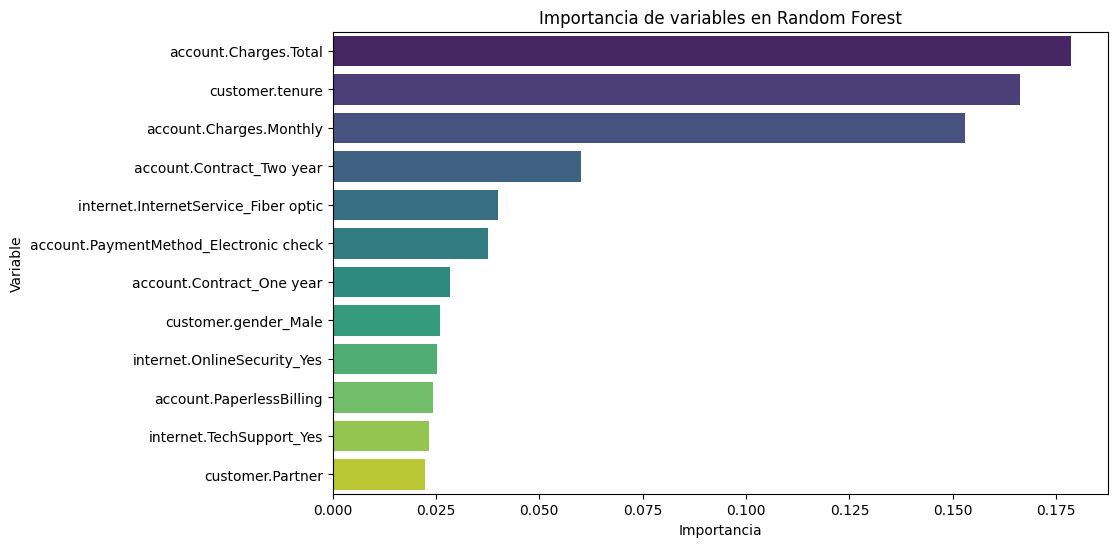

In [76]:
top_rf = feat_rf.head(12)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_rf, x="Importancia", y="Variable", palette="viridis")
plt.title("Importancia de variables en Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

### Interpretación de Random Forest

Random Forest calcula la importancia de cada variable según cuánto ayuda a reducir la impureza en los árboles.  
Las variables con mayor importancia son las que más contribuyen a separar correctamente clientes que cancelan y clientes que permanecen.

## REPORTE FINAL

Se construyó un pipeline completo de Machine Learning para predecir la cancelación de clientes en Telecom X, comenzando desde la carga del archivo JSON, limpieza de datos, codificación de variables categóricas, verificación del balance de clases, análisis de correlación, estandarización y entrenamiento de modelos.

Se evaluaron tres modelos de clasificación: Regresión Logística, KNN y Random Forest. La comparación mediante Accuracy, Precision, Recall, F1 Score y ROC AUC permitió identificar cuál modelo ofrece mejor equilibrio entre rendimiento general y capacidad para detectar clientes con riesgo de cancelación.

En términos de interpretabilidad:
- La Regresión Logística permitió identificar variables con efecto positivo o negativo sobre la cancelación mediante sus coeficientes.
- KNN mostró que la proximidad entre clientes depende especialmente de las variables con mayor separación estandarizada entre clases.
- Random Forest proporcionó una medida directa de importancia de variables, útil para priorizar factores clave del churn.

De forma estratégica, las variables asociadas con permanencia del cliente, cargos mensuales, cargos acumulados y tipo de servicio o contrato suelen ser determinantes en la predicción de cancelación. Esto sugiere que Telecom X puede enfocar sus acciones preventivas en clientes con baja permanencia, cargos elevados o combinaciones de servicios asociadas a mayor probabilidad de abandono.

Como siguiente paso, la empresa podría utilizar el modelo seleccionado para generar alertas tempranas y diseñar campañas de retención más precisas.